In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets
from sklearn.metrics import accuracy_score, confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Classificador StyleGAN2/Real

In [4]:
class VGG16Classifier(nn.Module):
    def __init__(self, num_classes=2, freeze_features=True):
        super().__init__()
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        if freeze_features:
            for param in self.vgg16.features.parameters():
                param.requires_grad = False

        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.vgg16(x)

checkpoint_path = '/home/vandrade/src/notebooks/cross-domain_morphs/checkpoints/stylegan2-classifier/best_vgg16_weights_stylegan2.pt'
model = VGG16Classifier(num_classes=2, freeze_features=True).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

<All keys matched successfully>

In [5]:
transformer_vgg16 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

### Conjunto de Teste: 167 fakes vs 167 reais

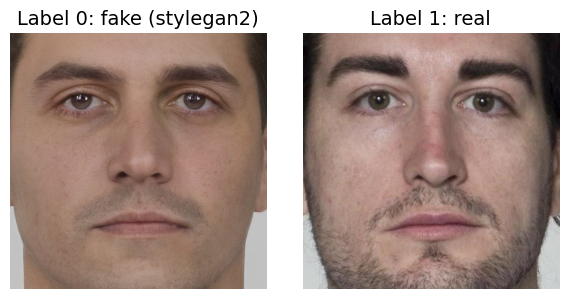

In [13]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan2_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_stylegan2 = None

for img, label in dataset_vis:
    if label == 0 and img_stylegan2 is None:
        img_stylegan2 = img
        label_stylegan2 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_stylegan2 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_stylegan2}: {classes[label_stylegan2]} (stylegan2)", fontsize=14)
axes[0].imshow(img_stylegan2)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [14]:
stg2_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan2_real/test', transform=transformer_vgg16)
stg2_test_loader = DataLoader(dataset=stg2_test_set, batch_size=32, shuffle=False)

print(f"classes: {stg2_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.9940


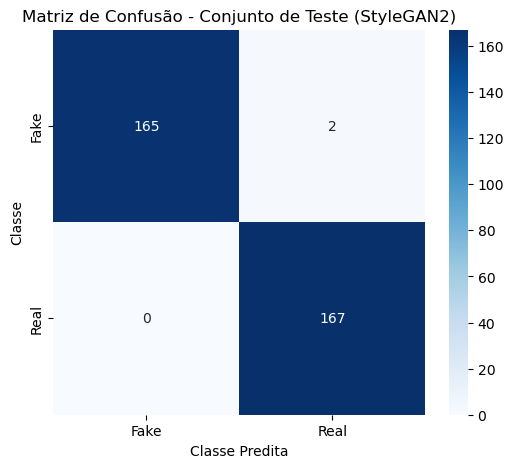

In [16]:
model.eval()

all_stg2_preds = []
all_stg2_targets = []

with torch.inference_mode():
    for X, y in stg2_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_stg2_preds.extend(preds.cpu().numpy())
        all_stg2_targets.extend(y.cpu().numpy())

acc_stg2 = accuracy_score(all_stg2_targets, all_stg2_preds)
print(f"Acurácia: {acc_stg2:.4f}")

cm = confusion_matrix(all_stg2_targets, all_stg2_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], 
            yticklabels=['Fake', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Conjunto de Teste (StyleGAN2)')
plt.show()

# Inferência MipGan2

### Conjunto de Teste: 167 fakes vs 167 reais

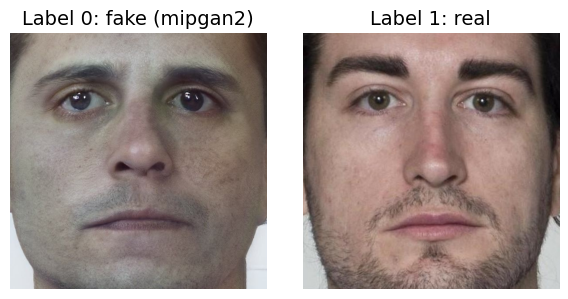

In [18]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/mipgan2_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_mipgan2 = None

for img, label in dataset_vis:
    if label == 0 and img_mipgan2 is None:
        img_mipgan2 = img
        label_mipgan2 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_mipgan2 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_mipgan2}: {classes[label_mipgan2]} (mipgan2)", fontsize=14)
axes[0].imshow(img_mipgan2)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [19]:
mip2_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/mipgan2_real/test', transform=transformer_vgg16)
mip2_test_loader = DataLoader(dataset=mip2_test_set, batch_size=32, shuffle=False)

print(f"classes: {mip2_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.7904


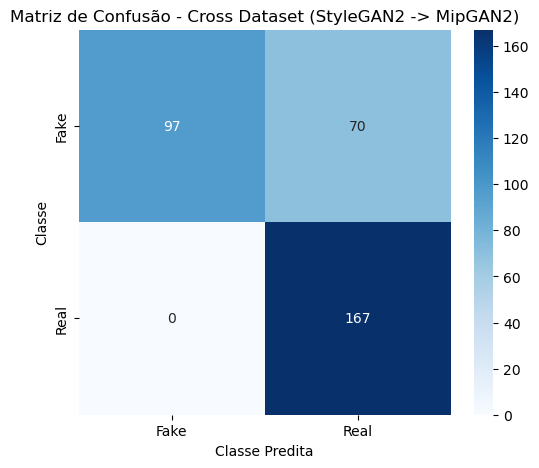

In [20]:
model.eval()

all_mip2_preds = []
all_mip2_targets = []

with torch.inference_mode():
    for X, y in mip2_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_mip2_preds.extend(preds.cpu().numpy())
        all_mip2_targets.extend(y.cpu().numpy())

acc_mip2 = accuracy_score(all_mip2_targets, all_mip2_preds)
print(f"Acurácia: {acc_mip2:.4f}")

cm = confusion_matrix(all_mip2_targets, all_mip2_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], 
            yticklabels=['Fake', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Cross Dataset (StyleGAN2 -> MipGAN2)')
plt.show()

# Inferência StyleGan3

### Conjunto de Teste: 167 fakes vs 167 reais

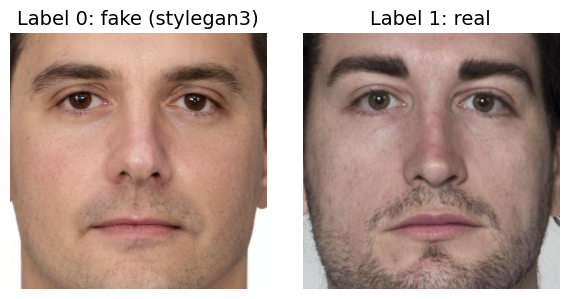

In [21]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_stylegan3 = None

for img, label in dataset_vis:
    if label == 0 and img_stylegan3 is None:
        img_stylegan3 = img
        label_stylegan3 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_stylegan3 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_stylegan3}: {classes[label_stylegan3]} (stylegan3)", fontsize=14)
axes[0].imshow(img_stylegan3)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [22]:
stg3_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/test', transform=transformer_vgg16)
stg3_test_loader = DataLoader(dataset=stg3_test_set, batch_size=32, shuffle=False)

print(f"classes: {stg3_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.8563


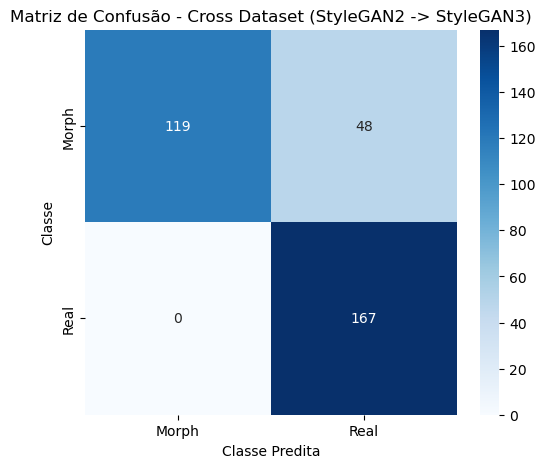

In [24]:
model.eval()

all_stg3_preds = []
all_stg3_targets = []

with torch.inference_mode():
    for X, y in stg3_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_stg3_preds.extend(preds.cpu().numpy())
        all_stg3_targets.extend(y.cpu().numpy())

acc_stg3 = accuracy_score(all_stg3_targets, all_stg3_preds)
print(f"Acurácia: {acc_stg3:.4f}")

cm = confusion_matrix(all_stg3_targets, all_stg3_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Morph', 'Real'], 
            yticklabels=['Morph', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Cross Dataset (StyleGAN2 -> StyleGAN3)')
plt.show()

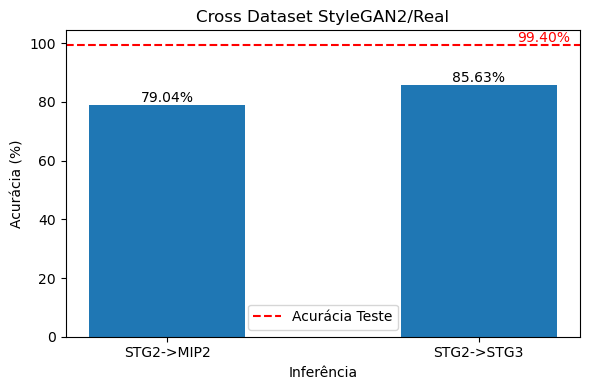

In [27]:
labels = ["STG2->MIP2", "STG2->STG3"]
values = [
    acc_mip2 * 100,
    acc_stg3 * 100
]

test_acc = acc_stg2 * 100

plt.figure(figsize=(6, 4))
ax = plt.gca()
bars = ax.bar(labels, values, width=0.5)
ax.set_title("Cross Dataset StyleGAN2/Real")
ax.set_xlabel("Inferência")
ax.set_ylabel("Acurácia (%)")
ax.bar_label(bars, fmt="%.2f%%")
ax.axhline(
    y=test_acc,
    linestyle="--",
    color="red",
    label="Acurácia Teste"
)
ax.text(
    0.98, test_acc,
    f"{test_acc:.2f}%",
    transform=ax.get_yaxis_transform(),
    ha="right",
    va="bottom",
    color="red"
)
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
import json
cross_data_stylegan2 = {
    "test_stg2" : acc_stg2,
    "cross_mip2": acc_mip2,
    "cross_stg3": acc_stg3
}

with open('metrics_cross_stylegan2.json', 'w') as arquivo:
    json.dump(cross_data_stylegan2, arquivo)